## Assessing if a matrix is PSD

Quick check to assess the validity of the generator and kernel matrix. 

### Preamble 

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import scipy.linalg
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from sklearn.metrics import adjusted_rand_score

from clustering.spectral import dist_mat, knn_affinity
from clustering.alc import ALCAdapter
from data.generators import make_blobs_convex, make_two_moons, make_rings

import matplotlib.gridspec as gridspec
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

from scipy.linalg import expm

### Data Generation 

In [2]:
blobs, blobs_labels = make_blobs_convex(N=500, num_clusters=7, n_features=5000)
rings, rings_labels = make_rings(n_points=500, n_circles=3, noise_std=0.5)
moons, moons_labels = make_two_moons(n_samples=500, noise=0.25)

print(blobs.shape, rings.shape, moons.shape)

(500, 5000) (500, 2) (500, 2)


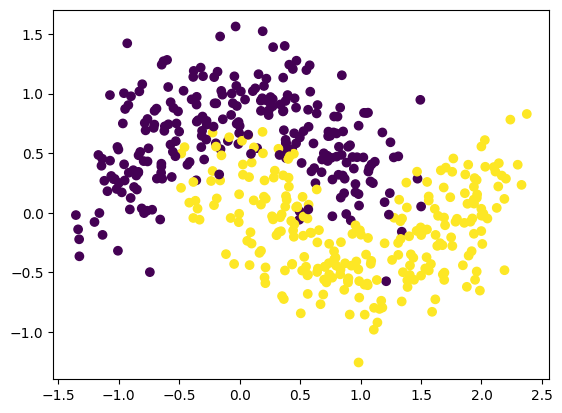

In [4]:
#plt.scatter(x=blobs[:,0], y=blobs[:,1], c=blobs_labels)
#plt.scatter(x=rings[:,0], y=rings[:,1], c=rings_labels)
plt.scatter(x=moons[:,0], y=moons[:,1], c=moons_labels)

### Affinity Matrix Construction 

In [24]:
# ---------------- Distance matrix ----------------
def dist_mat(X):
    """Compute pairwise Euclidean distances (N x N)."""
    return cdist(X, X, "euclidean")

# ---------------- k-nn affinity matrix ----------------
def knn_affinity(dist_matrix, k, sigma):
    """
    Build a symmetric k-NN Gaussian affinity matrix from a precomputed
    pairwise distance matrix.

    Parameters
    ----------
    dist_matrix : (n, n) ndarray  — pairwise Euclidean distances, zero diagonal.
    k           : int             — number of nearest neighbours per point.
    sigma       : float           — Gaussian kernel bandwidth.

    Returns
    -------
    A : (n, n) ndarray  — symmetric, non-negative, zero diagonal.
    """
    n = dist_matrix.shape[0]

    # Fully connected fallback (backward-compatible)
    if k >= n - 1:
        A = np.exp(-(dist_matrix ** 2 / (2.0 * sigma ** 2)))
        return A

    # Step 1 — k nearest neighbours per row (skip self at index 0)
    sorted_idx = np.argsort(dist_matrix, axis=1)
    nn_idx     = sorted_idx[:, 1:k + 1]          # (n, k)

    # Step 2 — directed adjacency mask
    nn_mask      = np.zeros((n, n), dtype=bool)
    rows         = np.repeat(np.arange(n), k)
    nn_mask[rows, nn_idx.ravel()] = True

    # Step 3 — OR-symmetrisation
    sym_mask = nn_mask | nn_mask.T

    # Step 4-5 — Gaussian weights applied to retained edges only
    W = np.exp(-(dist_matrix ** 2 / (2.0 * sigma ** 2)))
    A = W * sym_mask
    return A


In [25]:
# Finding Distance Matrices
blobs_dist_mat = dist_mat(blobs)
rings_dist_mat = dist_mat(rings)
moons_dist_mat = dist_mat(moons)

# Finding k-nn affinity matrices
blobs_affinity = knn_affinity(blobs_dist_mat, k=10, sigma=10)
rings_affinity = knn_affinity(rings_dist_mat, k=10, sigma=0.5)
moons_affinity = knn_affinity(moons_dist_mat, k=10, sigma=0.1)
rings_aff_full = knn_affinity(rings_dist_mat, k=1000, sigma=0.5)
moons_aff_full = knn_affinity(moons_dist_mat, k=1000, sigma=0.1)


### Diffusion Kernel 

In [26]:
def diffusion_kernel(affinity, t):
    diff_K = expm(-t * affinity) # matrix exponential *not* elementwise operator
    return(diff_K)

In [27]:
# Finding diffusion matrices
blobs_diff_1 = diffusion_kernel(blobs_affinity, t=3)
blobs_diff_2 = diffusion_kernel(blobs_affinity, t=100)
rings_diff_1 = diffusion_kernel(rings_affinity, t=3)
rings_diff_2 = diffusion_kernel(rings_affinity, t=100)
moons_diff_1 = diffusion_kernel(moons_affinity, t=2)
moons_diff_2 = diffusion_kernel(moons_affinity, t=100)

In [21]:
# ---------------- Distance matrix ----------------
def dist_mat(X):
    """Compute pairwise Euclidean distances (N x N)."""
    return cdist(X, X, "euclidean")

def fully_conn(dist_matrix, sigma):
    A = np.exp(-dist_matrix ** 2 / (2.0 * sigma ** 2))
    return A


In [22]:
fully_conn_aff = fully_conn(dist_matrix=moons_dist_mat, sigma=0.1)

### Postive Semi-Definite Check 

In [5]:
def check_psd(M, name="Matrix"):
    """
    Check whether a matrix satisfies the conditions for
    positive semi-definiteness. Reports each condition
    separately so you can see exactly where a matrix fails.
    """
    n = M.shape[0]
    eigenvalues = np.linalg.eigvalsh(M)
    
    # Condition 1: Symmetry
    # A PSD matrix must be symmetric (M = M^T).
    # The quadratic form x^T M x is only guaranteed real-valued
    # when M is symmetric. If M is not symmetric, the eigenvalues
    # can be complex and PSD is not even defined.
    is_symmetric = np.allclose(M, M.T)
    
    # Condition 2: All eigenvalues non-negative
    # This is the core definition. M is PSD if and only if
    # x^T M x >= 0 for all x. For a symmetric matrix, this
    # holds if and only if all eigenvalues are >= 0.
    # Because: M = U diag(lambda) U^T, so
    # x^T M x = sum_j lambda_j (u_j^T x)^2.
    # Each (u_j^T x)^2 >= 0, so the sum is non-negative
    # if and only if every lambda_j >= 0.
    min_eigenvalue = eigenvalues.min()
    n_negative = (eigenvalues < -1e-10).sum()  # tolerance for numerics
    is_psd = min_eigenvalue >= -1e-10
    
    # Condition 3: Non-negative diagonal
    # A necessary (but not sufficient) condition. The diagonal
    # entry M_ii = e_i^T M e_i, where e_i is the i-th standard
    # basis vector. If M is PSD, then e_i^T M e_i >= 0, so
    # M_ii >= 0. If any diagonal entry is negative, the matrix
    # cannot be PSD. But non-negative diagonal does NOT guarantee
    # PSD — your affinity matrix demonstrates this.
    min_diagonal = np.diag(M).min()
    has_nonneg_diag = min_diagonal >= -1e-10

    print(f"=== PSD check for {name} (shape {M.shape}) ===")
    print(f"  Symmetric:             {is_symmetric}")
    print(f"  Min diagonal entry:    {min_diagonal:.6e}  (non-negative: {has_nonneg_diag})")
    print(f"  Min eigenvalue:        {min_eigenvalue:.6e}")
    print(f"  Negative eigenvalues:  {n_negative} out of {n}")
    print(f"  PSD:                   {is_psd}")
    
    if not is_psd:
        # Show the five most negative eigenvalues so you can
        # gauge how badly PSD is violated
        worst = np.sort(eigenvalues)[:min(5, n)]
        print(f"  Five smallest eigenvalues: {worst}")
    
    print()
    return is_psd, eigenvalues




In [29]:
check_psd(M=moons_affinity, name="Full Moons Affinity")

=== PSD check for Full Moons Affinity (shape (500, 500)) ===
  Symmetric:             True
  Min diagonal entry:    0.000000e+00  (non-negative: True)
  Min eigenvalue:        -1.799898e+00
  Negative eigenvalues:  352 out of 500
  PSD:                   False
  Five smallest eigenvalues: [-1.7998979  -1.71865408 -1.67598216 -1.53822415 -1.53131708]



(np.False_,
 array([-1.79989790e+00, -1.71865408e+00, -1.67598216e+00, -1.53822415e+00,
        -1.53131708e+00, -1.50524053e+00, -1.49580977e+00, -1.48187783e+00,
        -1.46989948e+00, -1.46007193e+00, -1.45439955e+00, -1.45270490e+00,
        -1.42169594e+00, -1.39828959e+00, -1.39274944e+00, -1.38764664e+00,
        -1.37383736e+00, -1.36644682e+00, -1.35038158e+00, -1.34419308e+00,
        -1.33584186e+00, -1.33031239e+00, -1.31410392e+00, -1.30399906e+00,
        -1.29633542e+00, -1.28970620e+00, -1.28695664e+00, -1.28314600e+00,
        -1.27673759e+00, -1.27292494e+00, -1.26572847e+00, -1.25893968e+00,
        -1.24116796e+00, -1.24075702e+00, -1.23632847e+00, -1.22691805e+00,
        -1.22077655e+00, -1.21603466e+00, -1.20839837e+00, -1.20133953e+00,
        -1.19687723e+00, -1.19487203e+00, -1.19097265e+00, -1.18622577e+00,
        -1.18619598e+00, -1.18119002e+00, -1.17642259e+00, -1.17391423e+00,
        -1.16900797e+00, -1.16500628e+00, -1.15400346e+00, -1.15287264e+00,
